#Fine-Tuning
##Build a model for sentiment analysis with using pre-trained model, namely **distilbert-base-uncased**

In [1]:
!pip install -U transformers
!pip install -U datasets
!pip install -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 92.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 22.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hu

##Uploading train and evaluation sets

In [2]:
from datasets import load_dataset
dataset = load_dataset("nyu-mll/glue", "sst2")
small_train = dataset['train'].shuffle(seed=42).select([ i for i in range(2000)])
small_test = dataset['validation'].shuffle(seed=42).select([ i for i in range(400)])

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  148kB            

sst2/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

##Tokenizer

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def preprocess_function(examples):
    # Ensure token_type_ids are included for full compatibility with Trainer
    return tokenizer(examples['sentence'], padding = 'max_length', max_length = 128, truncation = True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [4]:
tokenized_train = small_train.map(preprocess_function, batched=True)
tokenized_test = small_test.map(preprocess_function, batched=True)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

##Model

In [5]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels = 2)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##Training

In [6]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir = './results',
    num_train_epochs = 2,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    logging_dir = './logs',
    logging_steps = 50,
    report_to = 'none',
    label_names=['labels'] # Specify the renamed label column name
)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized_train,
    eval_dataset = tokenized_test
)

trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
50,0.534047
100,0.333424
150,0.299322
200,0.210769
250,0.154573


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.30642711639404296, metrics={'train_runtime': 51.0837, 'train_samples_per_second': 78.303, 'train_steps_per_second': 4.894, 'total_flos': 132467398656000.0, 'train_loss': 0.30642711639404296, 'epoch': 2.0})

##Evaluate

In [7]:
trainer.evaluate()

Training Loss,Validation Loss,Step
0.154573,0.391310,250


{'eval_loss': 0.39131033420562744}

##Test with some texts

In [8]:
texts = ["this movie is a masterpiece",
         "a complete waste of time",
         "This movie has stars, no matter some strange scene"]


In [9]:
import torch
import torch.nn.functional as F
inputs = tokenizer(texts, padding = True, truncation = True, return_tensors = 'pt', max_length = 128).to('cuda')

with torch.no_grad():
  outputs = model(**inputs)
  probs = F.softmax(outputs.logits, dim = 1)
  predictions = torch.argmax(probs, dim=1)

label_map = {0:'negative',1:'positive'}
for text, pred, prob in zip(texts, predictions, probs):
  print(f"{text}, {label_map[pred.item()]}, {prob[pred.item()].item()}")



this movie is a masterpiece, positive, 0.9946449995040894
a complete waste of time, negative, 0.9871789216995239
This movie has stars, no matter some strange scene, positive, 0.9787160158157349


##Classification report and confusion matrix

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = trainer.predict(tokenized_test)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

In [12]:
label_names = ["Negative", "Positive"]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85       189
    Positive       0.87      0.87      0.87       211

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



<Axes: >

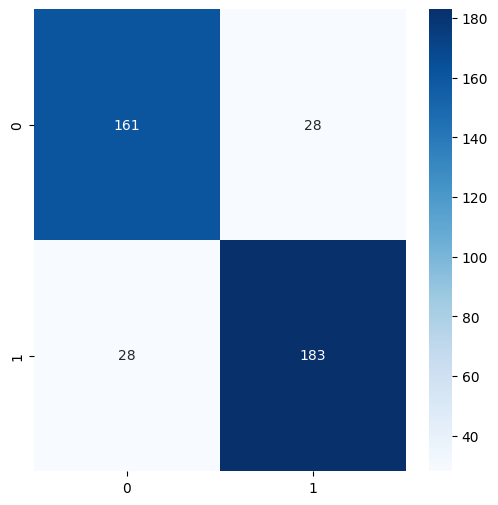

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, cmap = 'Blues', annot=True, fmt = 'd')

##Model deployment with gradio

In [22]:
def predict_news_category(text):
  inputs = tokenizer(text, padding=True, truncation = True, return_tensors='pt',max_length = 128).to('cuda')
  with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    label_names = {0: "Negative", 1: "Positive"}

  return f'Category: {label_names[pred]}, Probability: {probs[0, pred].item():.2f}'

In [24]:
import gradio as gr
interface = gr.Interface(
    fn = predict_news_category,
    inputs = 'text',
    outputs = 'text',
    title = 'The sentiment analysis',
    description="Enter a movie review to predict its label"
    )

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a784bc1719b57f1b00.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


##Save the model

In [25]:
torch.save(model.state_dict(), 'news_model.pth')